In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
results_path = "../results"
df5 = pd.read_csv(f'{results_path}/5_multi_bound.csv')
df10 = pd.read_csv(f'{results_path}/10_multi_bound.csv')
df20 = pd.read_csv(f'{results_path}/20_multi_bound.csv')
df50 = pd.read_csv(f'{results_path}/50_multi_bound.csv')

df = pd.concat([df5, df10, df20, df50], ignore_index=True)

In [18]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Split dataset markers
df_greedy = df[df['planner_type'] == 'greedy']
df_mb = df[df['planner_type'] == 'multi_bound']

# Create a consistent color palette across all heuristics
unique_heuristics = df['heuristic'].unique()
palette = sns.color_palette("Set2", len(unique_heuristics))
heuristic_colors = dict(zip(unique_heuristics, palette))

# Helper function to auto-label bar heights using version-safe formatting
def autolabel_bars(ax, format_str="%.1f"):
    """Iterates over bar containers to place numerical values above the bars."""
    for container in ax.containers:
        # Using %-style formatting (e.g., '%.1f' or '%.2f') works across all versions
        ax.bar_label(container, fmt=format_str, padding=3, fontsize=9)

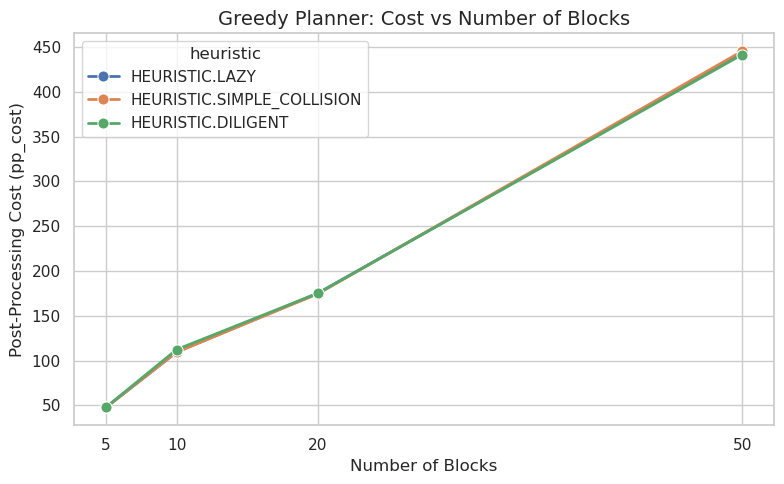

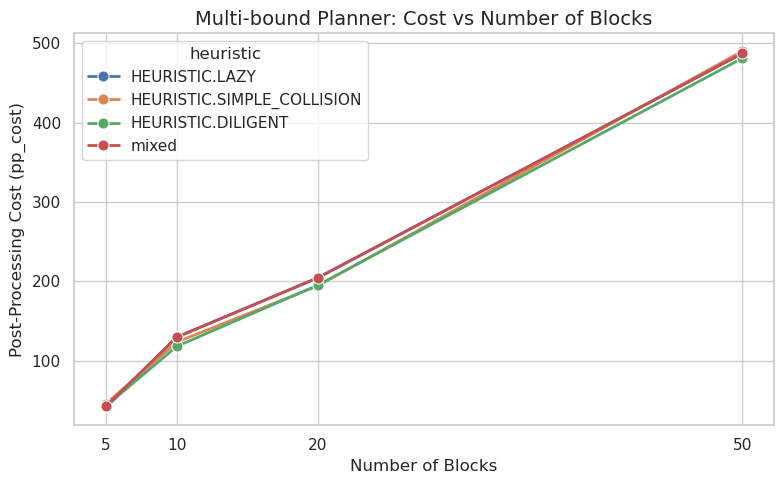

In [ ]:
# 1. Line plots for cost vs number of blocks
# Greedy Planner
df_greedy = df[df['planner_type'] == 'greedy'].sort_values('no.blocks')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_greedy, x='no.blocks', y='pp_cost', hue='heuristic', marker='o', ax=ax, linewidth=2, markersize=8)
ax.set_title('Greedy Planner: Cost vs Number of Blocks', fontsize=14)
ax.set_xlabel('Number of Blocks', fontsize=12)
ax.set_ylabel('Post-Processing Cost (pp_cost)', fontsize=12)
ax.set_xticks([5, 10, 20, 50])
plt.tight_layout()

# Multi-bound Planner
df_mb = df[df['planner_type'] == 'multi_bound'].sort_values('no.blocks')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_mb, x='no.blocks', y='pp_cost', hue='heuristic', marker='o', ax=ax, linewidth=2, markersize=8)
ax.set_title('Multi-bound Planner: Cost vs Number of Blocks', fontsize=14)
ax.set_xlabel('Number of Blocks', fontsize=12)
ax.set_ylabel('Post-Processing Cost (pp_cost)', fontsize=12)
ax.set_xticks([5, 10, 20, 50])
plt.tight_layout()
plt.show()

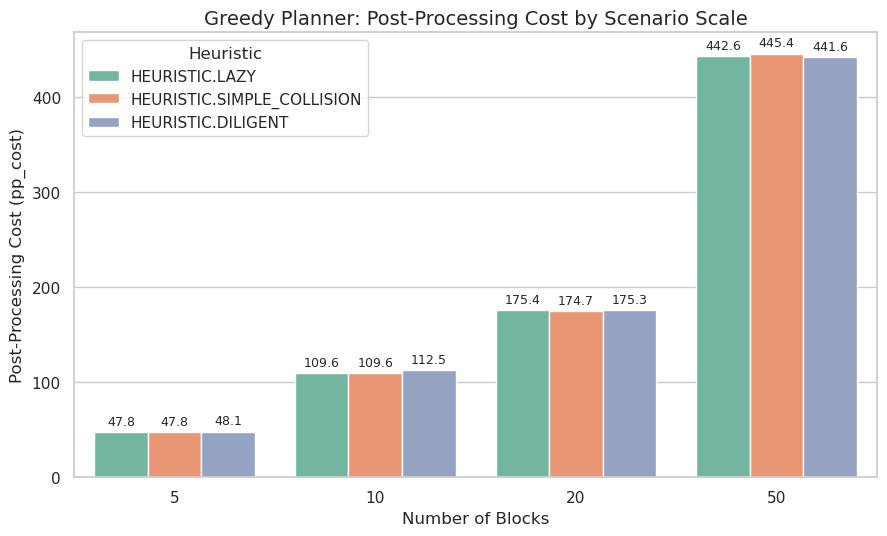

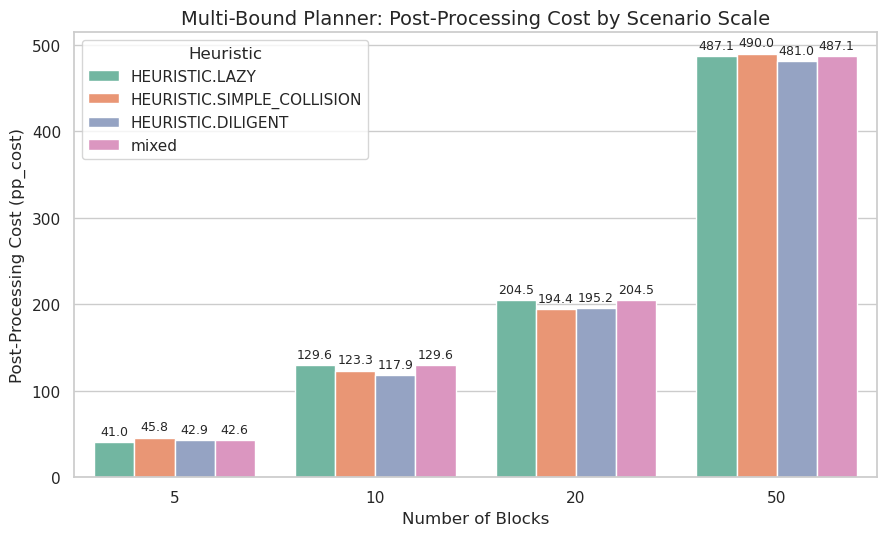

In [20]:
# ----------------- Figure 1: Greedy Planner Cost (Bar) -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_greedy, 
    x='no.blocks', 
    y='pp_cost', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Greedy Planner: Post-Processing Cost by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Post-Processing Cost (pp_cost)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()

# ----------------- Figure 2: Multi-Bound Planner Cost (Bar) -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_mb, 
    x='no.blocks', 
    y='pp_cost', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Multi-Bound Planner: Post-Processing Cost by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Post-Processing Cost (pp_cost)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()
plt.show()

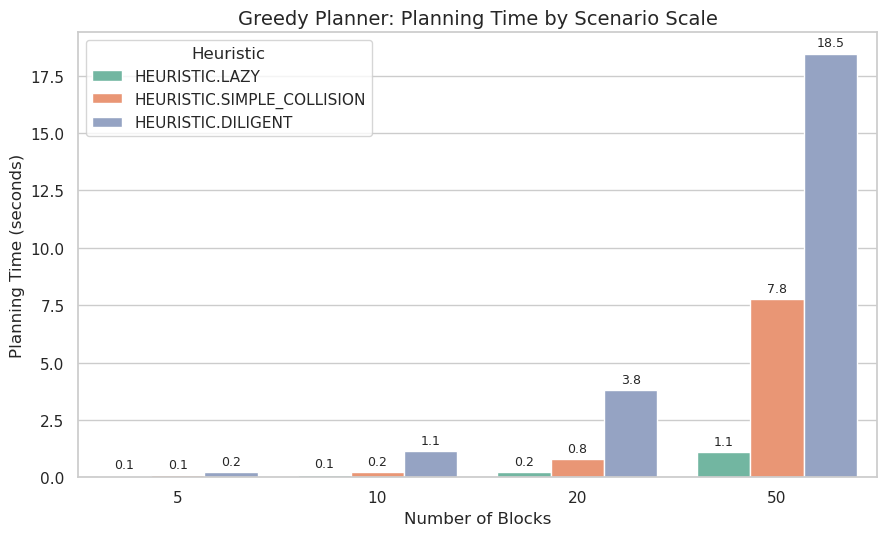

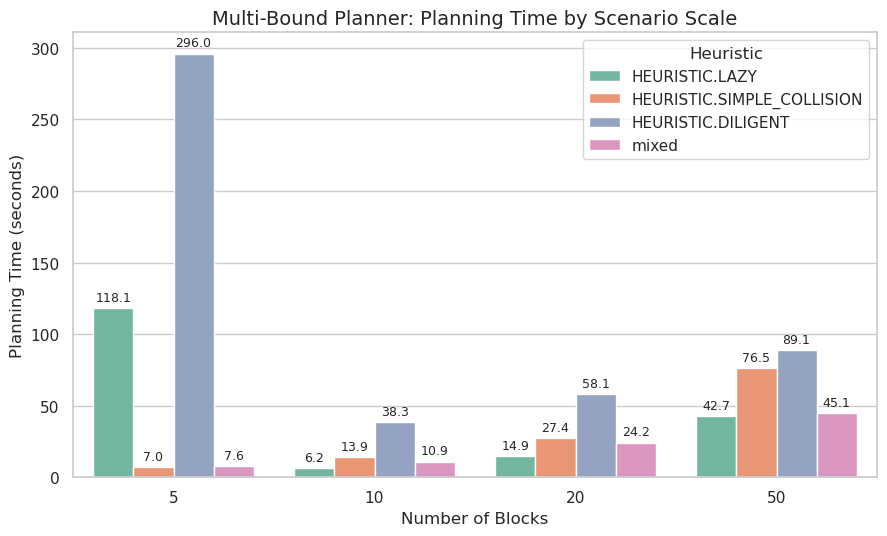

In [22]:
# ----------------- Figure 3: Greedy Planner Execution Time -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_greedy, 
    x='no.blocks', 
    y='planning_time', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Greedy Planner: Planning Time by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Planning Time (seconds)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper left')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()

# ----------------- Figure 4: Multi-Bound Planner Execution Time -----------------
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(
    data=df_mb, 
    x='no.blocks', 
    y='planning_time', 
    hue='heuristic', 
    palette=heuristic_colors,
    ax=ax
)
ax.set_title('Multi-Bound Planner: Planning Time by Scenario Scale')
ax.set_xlabel('Number of Blocks')
ax.set_ylabel('Planning Time (seconds)')

# Adjust legend and apply text annotations
ax.legend(title='Heuristic', loc='upper right')
autolabel_bars(ax, format_str="%.1f")

plt.tight_layout()
plt.show()